## Setup

First, we create a dedicated conda environment with all the libraries this notebook needs. Run the cell below — it will create the environment if it doesn't exist yet and register it as a Jupyter kernel.

After the cell completes, **switch your kernel** to `ml` (Kernel → Change Kernel → ml), then continue with the rest of the notebook.

In [16]:
import subprocess, os

CONDA = '/opt/homebrew/Caskroom/miniconda/base/bin/conda'
ENV_NAME = 'ml'
PACKAGES = ['tensorflow', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'ipykernel']

# Check if env already exists
result = subprocess.run([CONDA, 'env', 'list'], capture_output=True, text=True)
env_exists = any(ENV_NAME == line.split()[0] for line in result.stdout.splitlines() if line.strip() and not line.startswith('#'))

if not env_exists:
    print(f'Creating conda env "{ENV_NAME}" with Python 3.11...')
    subprocess.check_call([CONDA, 'create', '-n', ENV_NAME, 'python=3.11', '-y', '-q'])
    print('Environment created.')
else:
    print(f'Conda env "{ENV_NAME}" already exists, reusing.')

# Install packages into the env via pip
env_python = subprocess.check_output(
    [CONDA, 'run', '-n', ENV_NAME, 'which', 'python'], text=True
).strip()
print(f'Env Python: {env_python}')

print('Installing packages...')
subprocess.check_call([env_python, '-m', 'pip', 'install', '-q'] + PACKAGES)

# Register the env as a Jupyter kernel
subprocess.check_call([
    env_python, '-m', 'ipykernel', 'install', '--user',
    '--name', ENV_NAME, '--display-name', f'Python ({ENV_NAME})'
])

print(f'\nDone! Now switch your kernel to "Python ({ENV_NAME})" and run the next cell.')

Conda env "ml" already exists, reusing.
Env Python: /opt/homebrew/Caskroom/miniconda/base/envs/ml/bin/python
Installing packages...



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/Caskroom/miniconda/base/envs/ml/bin/python -m pip install --upgrade pip


Installed kernelspec ml in /Users/saurabh/Library/Jupyter/kernels/ml

Done! Now switch your kernel to "Python (ml)" and run the next cell.


# Training a Convolutional Neural Network on MNIST

## What We Will Build

In this notebook, we train a **Convolutional Neural Network (CNN)** to recognize handwritten digits from the **MNIST** dataset. By the end, you will understand:

- What a CNN is and why it works well for image recognition
- How to load and preprocess image data for a neural network
- How to define, compile, and train a CNN using TensorFlow/Keras
- How to evaluate the trained model with metrics like accuracy, confusion matrices, and classification reports
- How to save a trained model for later use

### What is MNIST?

MNIST is a dataset of 70,000 handwritten digit images (0 through 9), each 28x28 pixels in grayscale. It is the classic benchmark for image classification and a perfect starting point for learning about CNNs.

### What is a CNN?

A **Convolutional Neural Network** is a type of neural network designed specifically for processing grid-like data such as images. Unlike a standard neural network that treats each pixel independently, a CNN uses small sliding filters (called *kernels*) that scan across the image to detect patterns like edges, curves, and shapes. This makes CNNs far more effective at understanding spatial structure in images.

### Our Architecture (High-Level)

We will build a deliberately simple CNN with:
- **2 convolutional layers** (8 filters each) to detect patterns
- **2 pooling layers** to reduce spatial dimensions
- **2 dense (fully connected) layers** to classify based on detected features
- **Dropout layers** for regularization
- A **softmax output** that gives a probability for each of the 10 digits

This architecture is intentionally small so that the feature maps and activations are easy to visualize and understand.

## Section 2: Data Loading

Our MNIST data comes from Michael Nielsen's "Neural Networks and Deep Learning" book. It is stored as a compressed pickle file (`mnist.pkl.gz`). This format packages the data as Python objects serialized with Python 2, so we need to use `encoding='latin1'` when loading.

The file contains three datasets:
- **Training set** (50,000 images) -- used to train the model
- **Validation set** (10,000 images) -- used to monitor training progress
- **Test set** (10,000 images) -- used for final evaluation

Each image is stored as a flat vector of 784 values (28 x 28 pixels), with pixel intensities already normalized to the range [0, 1].

In [1]:
import gzip
import pickle
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the MNIST data from the Nielsen pickle file
with gzip.open('/Users/saurabh/Downloads/mnist.pkl.gz', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Nielsen format: 3-tuple of (images, labels) pairs
# Auto-detect structure in case the file uses a 2-tuple variant
if len(data) == 3:
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = data
    print("Loaded 3-tuple format (train/val/test)")
elif len(data) == 2:
    (x_train, y_train), (x_test, y_test) = data
    # Create validation split from training data
    x_val, y_val = x_train[50000:], y_train[50000:]
    x_train, y_train = x_train[:50000], y_train[:50000]
    print("Loaded 2-tuple format (train/test), split validation from training")

# Print shapes to verify the data loaded correctly
print(f"Training set:   {x_train.shape} images, {y_train.shape} labels")
print(f"Validation set: {x_val.shape} images, {y_val.shape} labels")
print(f"Test set:       {x_test.shape} images, {y_test.shape} labels")
print(f"Label range:    {y_train.min()} to {y_train.max()}")
print(f"Pixel dtype:    {x_train.dtype}, range: [{x_train.min():.3f}, {x_train.max():.3f}]")

Loaded 3-tuple format (train/val/test)
Training set:   (50000, 784) images, (50000,) labels
Validation set: (10000, 784) images, (10000,) labels
Test set:       (10000, 784) images, (10000,) labels
Label range:    0 to 9
Pixel dtype:    float32, range: [0.000, 0.996]


## Section 3: Preprocessing

### Why Reshape?

The data is currently stored as flat vectors of 784 values. But a CNN needs to understand the **spatial structure** of the image -- it needs to know which pixels are next to each other. So we reshape each vector back into a 28x28 grid.

We also add a **channel dimension**, making each image shape `(28, 28, 1)`. The "1" means grayscale (one color channel). Color images would have 3 channels (red, green, blue).

### Normalization Check

The Nielsen data is already normalized to [0, 1]. Many MNIST tutorials divide pixel values by 255, but that assumes raw integer pixel values (0-255). **We must NOT divide by 255 again** -- doing so would squash our data to near-zero and the model would fail to learn.

In [3]:
# CRITICAL: Verify that data is already in [0, 1] range
# Nielsen data is pre-normalized -- do NOT divide by 255
assert x_train.max() <= 1.0, f"Data max is {x_train.max()}, expected <= 1.0"
assert x_train.min() >= 0.0, f"Data min is {x_train.min()}, expected >= 0.0"
print(f"Data range confirmed: [{x_train.min():.3f}, {x_train.max():.3f}] -- no normalization needed")

Data range confirmed: [0.000, 0.996] -- no normalization needed


In [4]:
# Reshape from flat vectors (N, 784) to 2D images (N, 28, 28, 1)
# The extra dimension of 1 is the grayscale channel
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Reshaped training set:   {x_train.shape}")
print(f"Reshaped validation set: {x_val.shape}")
print(f"Reshaped test set:       {x_test.shape}")

Reshaped training set:   (50000, 28, 28, 1)
Reshaped validation set: (10000, 28, 28, 1)
Reshaped test set:       (10000, 28, 28, 1)


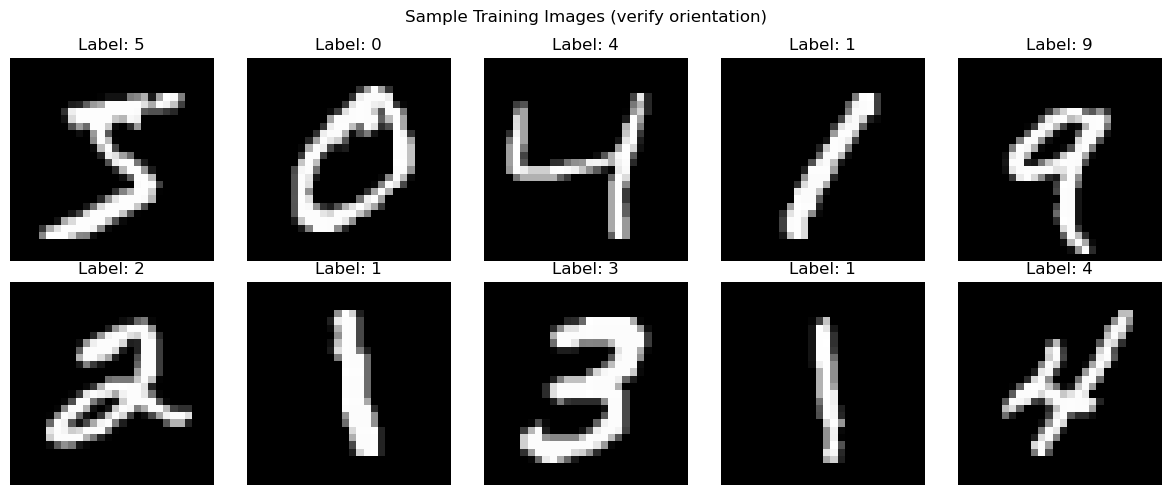

In [5]:
# Display 10 sample images to verify the reshape preserved spatial structure
# If digits look correct (not rotated, scrambled, or blank), the reshape is right
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample Training Images (verify orientation)")
plt.tight_layout()
plt.show()

### A Note on Labels

Our labels are integers (0 through 9). Some tutorials convert these to **one-hot encoded** vectors, where the label 3 becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. We skip that step because we use `sparse_categorical_crossentropy` as our loss function, which works directly with integer labels. This keeps the code simpler.

## Section 4: Model Architecture

Now we define the CNN. Here is what each layer type does:

### Conv2D (Convolutional Layer)
A convolution layer slides small filters (kernels) across the input image. Each filter learns to detect a specific pattern -- early filters detect simple features like edges and corners, while deeper filters detect more complex shapes. We use 8 filters per layer, each 3x3 pixels.

### MaxPooling2D (Pooling Layer)
After convolution, pooling reduces the spatial dimensions by taking the maximum value in each small region (2x2 in our case). This makes the representation smaller and more robust to small shifts in the input.

### Flatten
Converts the 2D feature maps into a 1D vector so it can be fed into dense layers.

### Dense (Fully Connected Layer)
Every neuron connects to every neuron in the previous layer. These layers learn to classify based on the features extracted by the convolutional layers.

### Dropout
During training, dropout randomly "turns off" a fraction of neurons (25% in our case). This prevents the model from memorizing the training data (overfitting) and forces it to learn more robust features.

### Softmax (Output)
The final layer has 10 neurons (one per digit). Softmax converts the raw outputs into probabilities that sum to 1. The digit with the highest probability is the model's prediction.

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the CNN using Sequential API (layers stacked one after another)
# Every layer has an explicit name= parameter for Phase 2 activation extraction
model = keras.Sequential([
    # Input shape: 28x28 grayscale images
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block: 8 filters detect basic patterns (edges, curves)
    layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='conv2d_1'),
    layers.MaxPooling2D(pool_size=(2, 2), name='maxpool_1'),

    # Second convolutional block: 8 filters detect higher-level features
    layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='conv2d_2'),
    layers.MaxPooling2D(pool_size=(2, 2), name='maxpool_2'),

    # Flatten the 2D feature maps into a 1D vector
    layers.Flatten(name='flatten'),

    # Dense layers for classification
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dropout(0.25, name='dropout_1'),     # Regularization: drop 25% of neurons
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.Dropout(0.25, name='dropout_2'),

    # Output layer: 10 classes (digits 0-9), softmax gives probabilities
    layers.Dense(10, activation='softmax', name='output'),
])

print("Model built successfully: %d layers, %d parameters." % (len(model.layers), model.count_params()))

Model built successfully: 10 layers, 35298 parameters.


In [7]:
# Display the model architecture and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,298 (137.88 KB)

 Trainable params: 35,298 (137.88 KB)

 Non-trainable params: 0 (0.00 B)

### Reading the Summary

The summary shows each layer, its output shape, and how many trainable parameters it has:

- **Conv2D layers**: Parameters = (kernel_height x kernel_width x input_channels x num_filters) + num_filters (bias). For conv2d_1: (3 x 3 x 1 x 8) + 8 = 80 parameters.
- **MaxPooling layers**: No trainable parameters -- they just take the max value.
- **Dense layers**: Parameters = (input_size x output_size) + output_size (bias). The first dense layer has the most parameters because it connects the flattened feature maps to 128 neurons.
- **Dropout layers**: No parameters -- they just randomly zero out neurons during training.
- **Total parameters**: This is a deliberately small model for pedagogical clarity. Production models may have millions of parameters.

## Section 5: Training

### Compilation

Before training, we **compile** the model by specifying:

- **Optimizer: Adam** -- An adaptive learning rate optimizer that adjusts how much to update each weight. It is the most popular default choice because it works well without manual tuning.
- **Loss: sparse_categorical_crossentropy** -- Measures how wrong the model's predictions are. "Sparse" means our labels are integers (not one-hot). "Categorical crossentropy" is the standard loss for multi-class classification.
- **Metrics: accuracy** -- The fraction of correctly classified images. We track this alongside the loss.

### Training Process

Training works in **epochs** (passes through the entire dataset). In each epoch:
1. The training data is split into **batches** (128 images at a time)
2. For each batch, the model makes predictions, calculates the loss, and adjusts its weights (backpropagation)
3. After all batches, the model is evaluated on the **validation set** to check for overfitting

We train for 15 epochs, which is enough for this model to converge on MNIST.

In [8]:
# Compile the model: define how it learns
model.compile(
    optimizer='adam',                          # Adaptive learning rate
    loss='sparse_categorical_crossentropy',    # For integer labels
    metrics=['accuracy']                       # Track classification accuracy
)

print("Model compiled with Adam optimizer and sparse categorical crossentropy loss.")

Model compiled with Adam optimizer and sparse categorical crossentropy loss.


In [9]:
# Train the model
# - epochs=15: pass through the full training set 15 times
# - batch_size=128: process 128 images at a time
# - validation_data: evaluate on validation set after each epoch
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6533 - loss: 1.0653 - val_accuracy: 0.9639 - val_loss: 0.1228
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9466 - loss: 0.1787 - val_accuracy: 0.9771 - val_loss: 0.0829
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9614 - loss: 0.1339 - val_accuracy: 0.9786 - val_loss: 0.0707
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9678 - loss: 0.1064 - val_accuracy: 0.9825 - val_loss: 0.0645
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9728 - loss: 0.0900 - val_accuracy: 0.9850 - val_loss: 0.0569
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9770 - loss: 0.0725 - val_accuracy: 0.9854 - val_loss: 0.0510
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9783 - loss: 0.0731 - val_accuracy: 0.9862 - val_loss: 0.0520
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9812 - loss: 0.0636 - val_accuracy: 0.

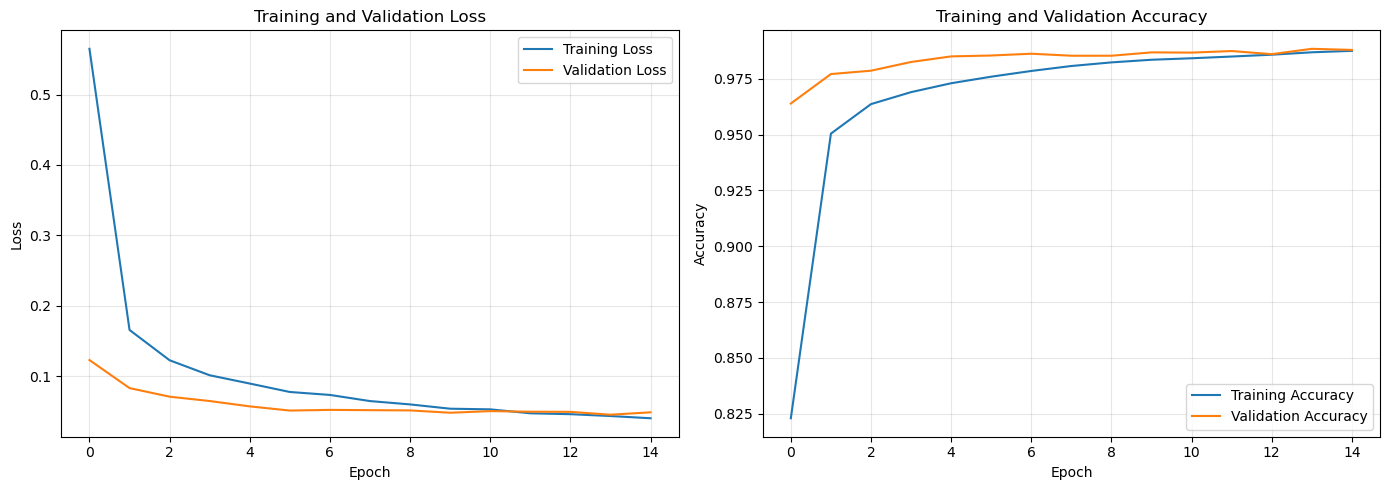

In [10]:
# Plot training curves to visualize learning progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves (lower is better)
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves (higher is better)
ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Evaluation

Training accuracy tells us how well the model learned the training data, but the real test is how it performs on **data it has never seen**. That is what the held-out test set is for.

We evaluate using:
1. **Overall test accuracy** -- a single number summarizing performance
2. **Confusion matrix** -- shows which digits get confused with each other
3. **Classification report** -- per-digit precision, recall, and F1 score

In [11]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

Test Loss:     0.0359
Test Accuracy: 0.9890 (98.9%)


In [12]:
# Get predictions for the full test set
y_pred = model.predict(x_test).argmax(axis=1)

print("Predictions generated for %d test images." % len(y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predictions generated for 10000 test images.


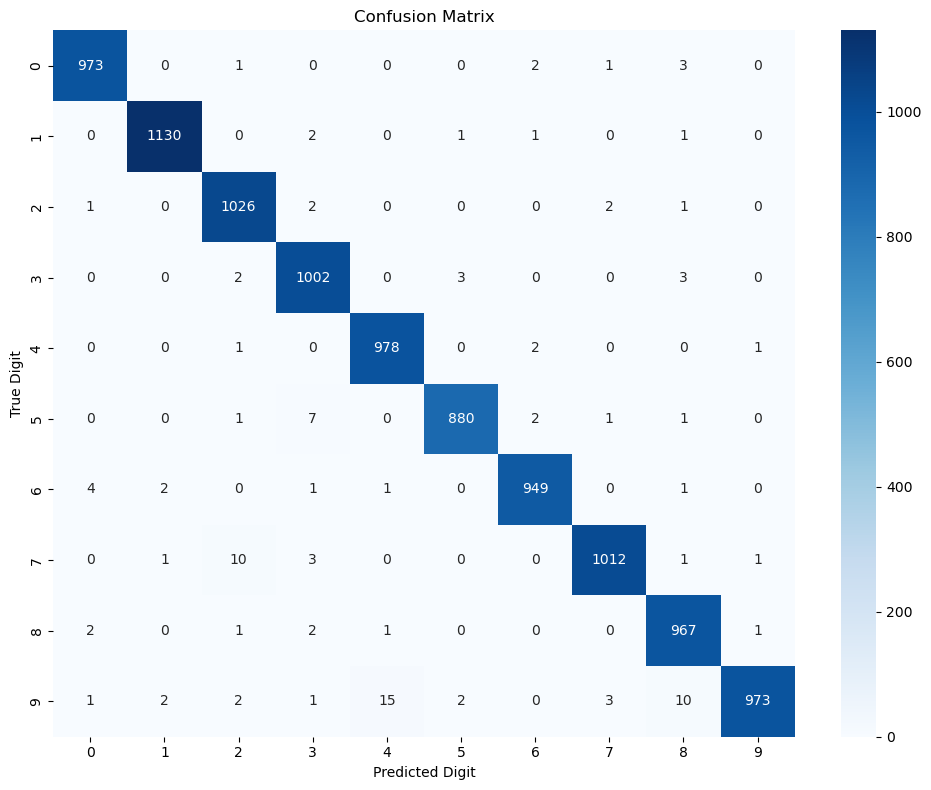

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Build and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### How to Read the Confusion Matrix

- **Diagonal cells** (top-left to bottom-right) show **correct** predictions. Larger numbers on the diagonal are better.
- **Off-diagonal cells** show **errors** -- the row is the true label and the column is what the model predicted. For example, if the cell at row 4, column 9 has a high value, the model is frequently misclassifying 4s as 9s.
- Common confusions include 4/9 (similar top curves), 3/5 (similar shapes), and 7/1 (both have a vertical stroke).

In [14]:
# Classification report: per-digit precision, recall, and F1-score
# - Precision: of all images predicted as digit X, what fraction actually are X?
# - Recall: of all actual digit X images, what fraction did the model find?
# - F1-score: harmonic mean of precision and recall
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.992     0.993     0.992       980
           1      0.996     0.996     0.996      1135
           2      0.983     0.994     0.988      1032
           3      0.982     0.992     0.987      1010
           4      0.983     0.996     0.989       982
           5      0.993     0.987     0.990       892
           6      0.993     0.991     0.992       958
           7      0.993     0.984     0.989      1028
           8      0.979     0.993     0.986       974
           9      0.997     0.964     0.980      1009

    accuracy                          0.989     10000
   macro avg      0.989     0.989     0.989     10000
weighted avg      0.989     0.989     0.989     10000



### Interpreting the Results

Look at the per-digit F1 scores. Digits that are visually similar (like 4 and 9, or 3 and 5) tend to have slightly lower scores. The overall accuracy should be above 95%, which is impressive given our deliberately simple model with only 8 filters per convolutional layer.

## Section 7: Model Export

We save the trained model as a `.keras` file (native Keras format). This is a single portable file that contains:
- The model architecture (layer definitions)
- The trained weights (what the model learned)
- The optimizer state (for resuming training if needed)

The backend API (Phase 2) will load this exact file to serve predictions and to extract intermediate layer activations for visualization. This is why we gave every layer an explicit `name=` parameter -- the backend references layers by name.

In [15]:
import os

# Create the model directory and save
os.makedirs('model', exist_ok=True)
model.save('model/mnist_cnn.keras')
print("Model saved to model/mnist_cnn.keras")
print(f"File size: {os.path.getsize('model/mnist_cnn.keras') / 1024:.1f} KB")

Model saved to model/mnist_cnn.keras
File size: 459.7 KB


In [16]:
# Verify: reload the model from disk and confirm it works
loaded = keras.models.load_model('model/mnist_cnn.keras')
loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,896 (413.66 KB)

 Trainable params: 35,298 (137.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,598 (275.78 KB)

In [17]:
# Verify Phase 2 compatibility: build a multi-output model for activation extraction
# This is the exact pattern the backend will use to visualize what happens inside the CNN

# Build a new Functional model that passes input through each layer and captures outputs
inp = keras.Input(shape=(28, 28, 1))
intermediate_outputs = []
x = inp
for layer in loaded.layers:
    x = layer(x)
    intermediate_outputs.append(x)

activation_model = keras.Model(inputs=inp, outputs=intermediate_outputs)

# Test with one sample image
sample = x_test[0:1]
activations = activation_model.predict(sample, verbose=0)

print(f"Activation extraction works: {len(activations)} layer outputs")
for i, act in enumerate(activations):
    print(f"  Layer {i} ({loaded.layers[i].name}): shape {act.shape}")

Activation extraction works: 10 layer outputs
  Layer 0 (conv2d_1): shape (1, 26, 26, 8)
  Layer 1 (maxpool_1): shape (1, 13, 13, 8)
  Layer 2 (conv2d_2): shape (1, 11, 11, 8)
  Layer 3 (maxpool_2): shape (1, 5, 5, 8)
  Layer 4 (flatten): shape (1, 200)
  Layer 5 (dense_1): shape (1, 128)
  Layer 6 (dropout_1): shape (1, 128)
  Layer 7 (dense_2): shape (1, 64)
  Layer 8 (dropout_2): shape (1, 64)
  Layer 9 (output): shape (1, 10)


## Section 8: Layer-by-Layer Activation Visualization

Now that we have a trained model and can extract activations, let's **see what happens inside the CNN** when it processes an image. This is the core educational value of the project — understanding not just *what* the model predicts, but *how* it arrives at that prediction.

We'll pass a single test image through the network and visualize the output of every layer:

| Layer | Type | What It Shows |
|-------|------|---------------|
| conv2d_1 | Conv2D | 8 feature maps (26×26) — edges, gradients, basic patterns |
| maxpool_1 | MaxPooling2D | 8 downsampled maps (13×13) — same features, half resolution |
| conv2d_2 | Conv2D | 8 feature maps (11×11) — combinations of Layer 1 features |
| maxpool_2 | MaxPooling2D | 8 downsampled maps (5×5) — compressed abstract features |
| dense_1 | Dense | 128 neuron activations — classification-relevant features |
| dense_2 | Dense | 64 neuron activations — refined decision features |
| output | Dense (softmax) | 10 probabilities — one per digit class |

**Key insight:** As we go deeper into the network, the representations become more abstract. Early layers detect simple visual patterns (edges, corners), while later layers combine those patterns into digit-specific features.

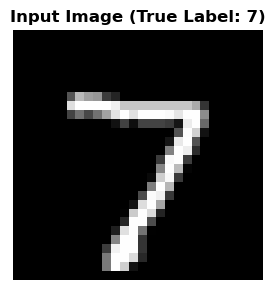

Image shape: (28, 28, 1) (28×28 pixels, 1 grayscale channel)
Pixel range: [0.000, 0.996]


In [18]:
# Pick a sample image and show what the CNN will process
sample_idx = 0
sample_image = x_test[sample_idx:sample_idx+1]
sample_label = y_test[sample_idx]

# Get all layer activations for this single image
activations = activation_model.predict(sample_image, verbose=0)

# Show the input image
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample_image[0].squeeze(), cmap='gray')
ax.set_title(f"Input Image (True Label: {sample_label})", fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {sample_image.shape[1:]} (28×28 pixels, 1 grayscale channel)")
print(f"Pixel range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")

### Layer 1: Conv2D — First Convolutional Layer (26×26, 8 filters)

The first convolutional layer slides eight 3×3 filters across the input image. Each filter learns to detect a different low-level pattern:

- **Edge detectors:** Some filters respond strongly to horizontal, vertical, or diagonal edges
- **Gradient detectors:** Some highlight areas where pixel intensity changes rapidly
- **Blob detectors:** Some respond to dark or light regions

The output is **8 feature maps**, each 26×26 pixels (slightly smaller than the input because the 3×3 filter can't extend past the borders without padding). Bright areas in each feature map indicate where the filter detected its target pattern.

**Why 26×26?** A 3×3 filter on a 28×28 image produces a (28-3+1) = 26×26 output. Each output pixel summarizes a 3×3 region of the input.

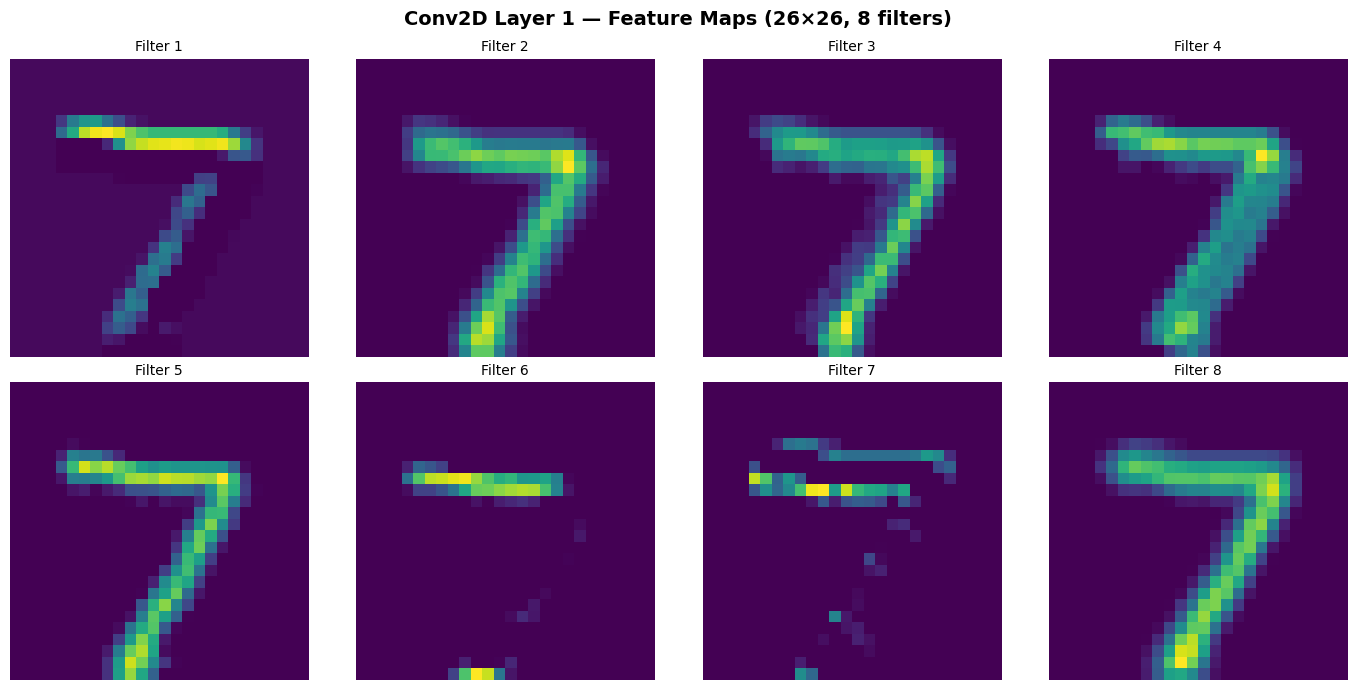

Shape: (26, 26, 8) — 8 feature maps, each 26×26 pixels
Activation range: [0.000, 1.871]
Note: ReLU activation means all values ≥ 0 (negative responses are clipped to zero)


In [19]:
# Layer 0: Conv2D Layer 1 — 8 feature maps at 26×26
conv1_act = activations[0][0]  # shape: (26, 26, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Conv2D Layer 1 — Feature Maps (26×26, 8 filters)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(conv1_act[:, :, i], cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape: {conv1_act.shape} — 8 feature maps, each 26×26 pixels")
print(f"Activation range: [{conv1_act.min():.3f}, {conv1_act.max():.3f}]")
print(f"Note: ReLU activation means all values ≥ 0 (negative responses are clipped to zero)")

### Layer 2: MaxPooling2D — First Pooling Layer (13×13)

Max pooling takes each 2×2 block of pixels and keeps only the **maximum** value. This:

1. **Halves the spatial dimensions** (26×26 → 13×13), reducing computation by 4×
2. **Provides translation invariance** — if a feature shifts by 1 pixel, the max in the 2×2 window often stays the same
3. **Preserves the strongest activations** — only the most confident detections survive

Notice that the pooled feature maps look very similar to the conv maps above, just at half resolution. The key information is preserved.

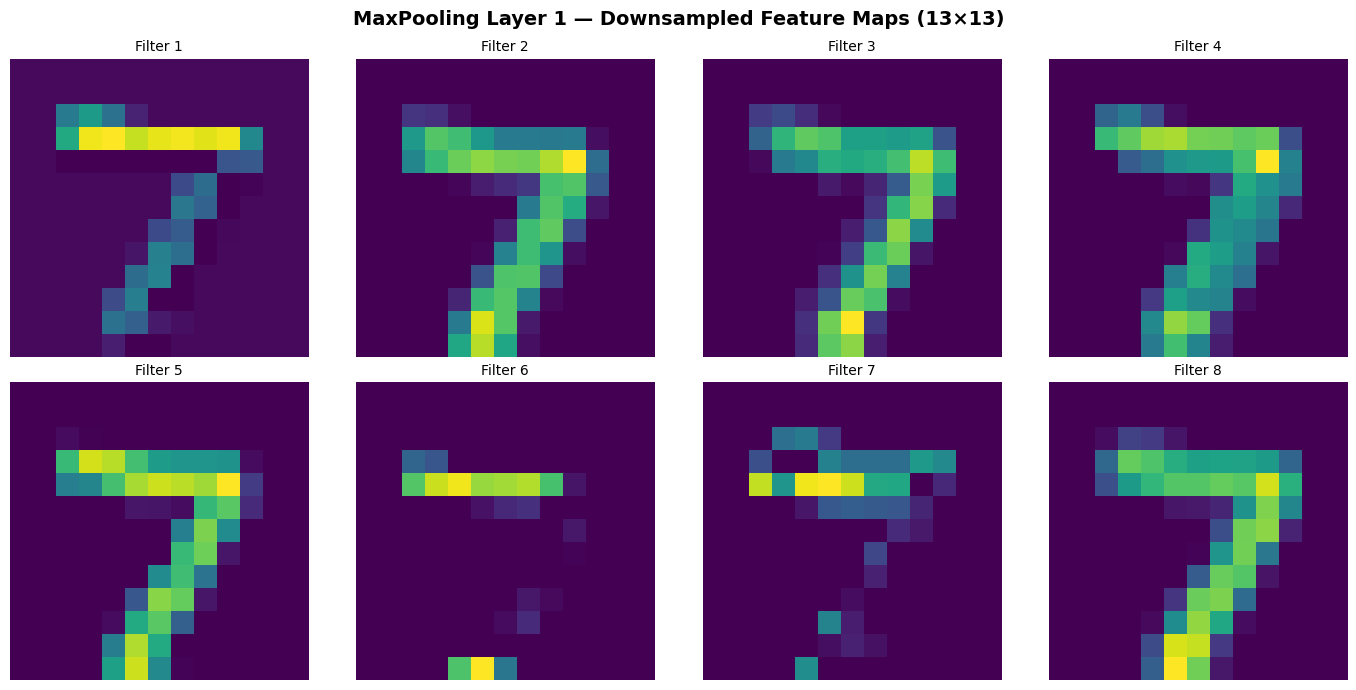

Shape: (13, 13, 8) — 8 feature maps, each 13×13 pixels (halved from 26×26)
Compression: 5408 values → 1352 values (25% of original)


In [20]:
# Layer 1: MaxPooling Layer 1 — 8 feature maps at 13×13
pool1_act = activations[1][0]  # shape: (13, 13, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("MaxPooling Layer 1 — Downsampled Feature Maps (13×13)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(pool1_act[:, :, i], cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape: {pool1_act.shape} — 8 feature maps, each 13×13 pixels (halved from 26×26)")
print(f"Compression: {26*26*8} values → {13*13*8} values ({13*13*8/(26*26*8)*100:.0f}% of original)")

### Layer 3: Conv2D — Second Convolutional Layer (11×11, 8 filters)

The second convolutional layer operates on the **pooled feature maps from Layer 2**, not the original image. Each of its 8 filters now combines patterns detected by the first layer:

- Where Layer 1 detected individual edges, Layer 2 might detect **corners** (two edges meeting)
- Where Layer 1 detected gradients, Layer 2 might detect **curves** or **strokes**
- The receptive field is now effectively larger — each pixel here summarizes a 7×7 region of the original image

**Why do these maps look more abstract?** The 11×11 resolution means each pixel represents a much larger area of the original image. The network is building increasingly abstract representations of the digit's structure.

**Parameter count:** Each filter here has (3×3×8) + 1 = 73 parameters (8 input channels from the previous layer), for a total of 8 × 73 = 584 parameters.

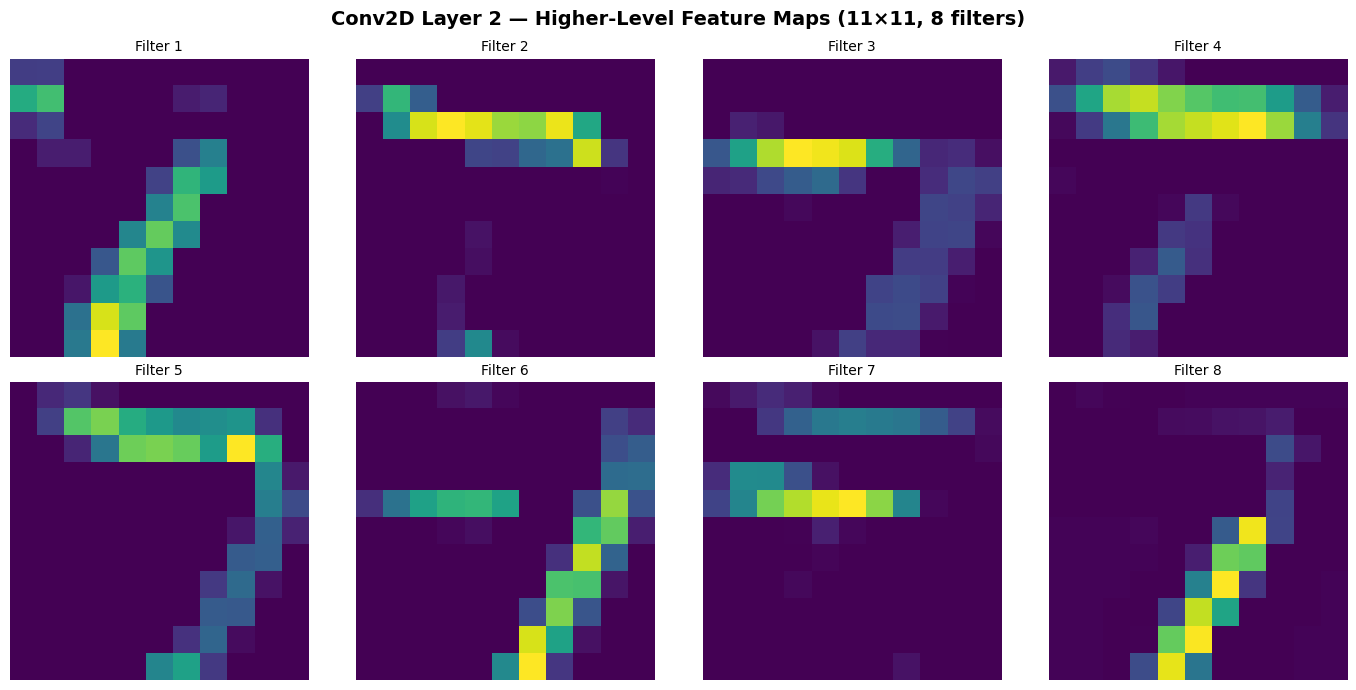

Shape: (11, 11, 8) — 8 feature maps, each 11×11 pixels
These maps combine patterns from Layer 1 into higher-level features


In [21]:
# Layer 2: Conv2D Layer 2 — 8 feature maps at 11×11
conv2_act = activations[2][0]  # shape: (11, 11, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Conv2D Layer 2 — Higher-Level Feature Maps (11×11, 8 filters)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(conv2_act[:, :, i], cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape: {conv2_act.shape} — 8 feature maps, each 11×11 pixels")
print(f"These maps combine patterns from Layer 1 into higher-level features")

### Layer 4: MaxPooling2D — Second Pooling Layer (5×5)

The second pooling layer halves the spatial dimensions again (11×11 → 5×5). At this point, each of the 8 feature maps is just 5×5 = 25 values. The entire spatial representation of the digit has been compressed from 784 pixels down to 200 values (5 × 5 × 8).

This is the **last spatial layer** — after this, the Flatten layer will convert these 2D maps into a single 1D vector for the dense classification layers.

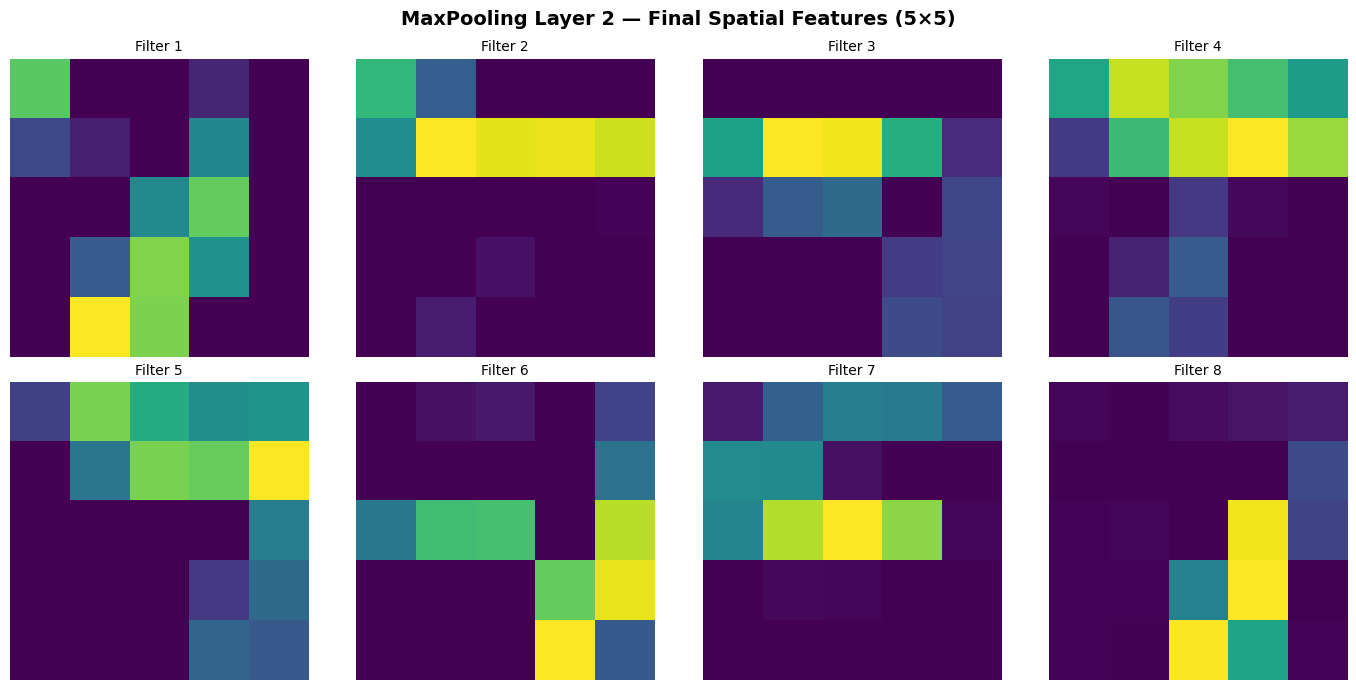

Shape: (5, 5, 8) — 8 feature maps, each 5×5 pixels
Total spatial representation: 200 = 200 values (down from 784 input pixels)
Compression ratio: 3.9× — the CNN distilled the image to its essential features


In [22]:
# Layer 3: MaxPooling Layer 2 — 8 feature maps at 5×5
pool2_act = activations[3][0]  # shape: (5, 5, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("MaxPooling Layer 2 — Final Spatial Features (5×5)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(pool2_act[:, :, i], cmap='viridis', interpolation='nearest')
    ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape: {pool2_act.shape} — 8 feature maps, each 5×5 pixels")
print(f"Total spatial representation: {5*5*8} = 200 values (down from 784 input pixels)")
print(f"Compression ratio: {784/200:.1f}× — the CNN distilled the image to its essential features")

### Layers 5-6: Dense Layers — From Features to Classification

After the Flatten layer converts the 5×5×8 feature maps into a 200-element vector, the dense (fully connected) layers take over. These layers no longer have any spatial awareness — they work purely with numerical features:

- **Dense Layer 1 (128 neurons):** Each neuron connects to all 200 flattened values and learns a weighted combination. Together, 128 neurons capture different aspects of "what digit is this?"
- **Dense Layer 2 (64 neurons):** Further refines the 128-dimensional representation into 64 dimensions, focusing on the most discriminative features

We visualize these as **activation bar charts** — each bar represents one neuron's activation level. Higher values mean that neuron detected a pattern it was trained to recognize. Note that many neurons will be zero (ReLU clipping), meaning those features weren't present in this particular image.

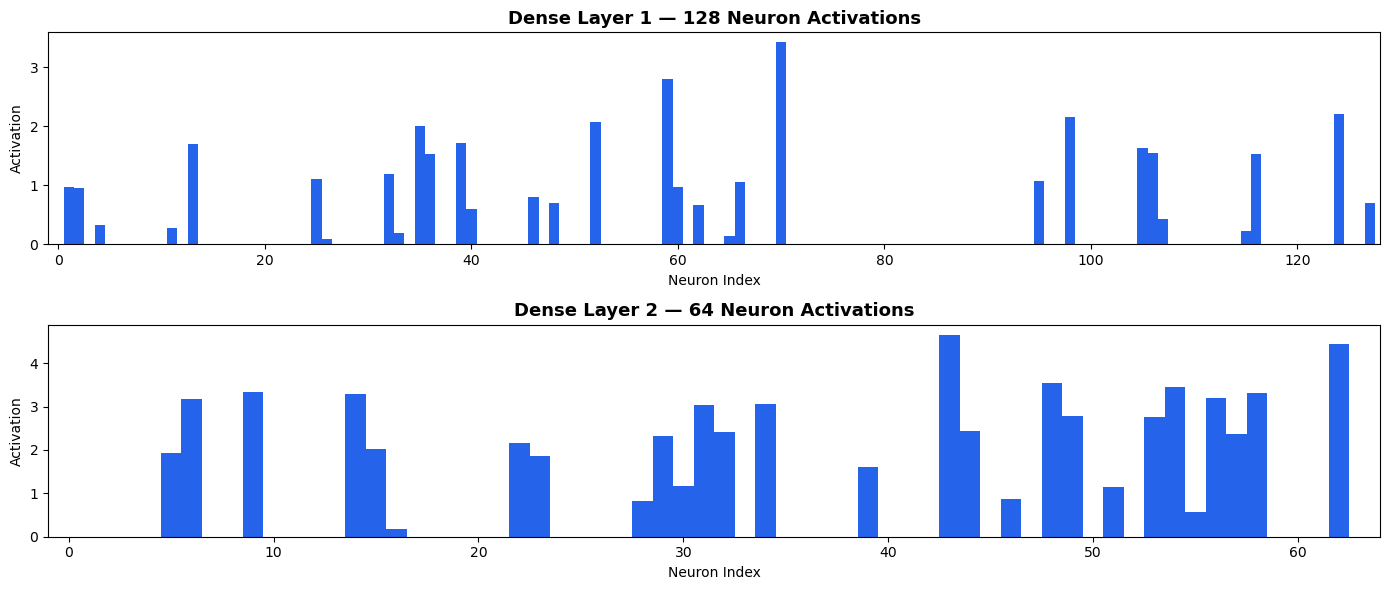

Dense Layer 1: 31/128 neurons active (24%) — max activation: 3.422
Dense Layer 2: 29/64 neurons active (45%) — max activation: 4.652
Inactive neurons (value = 0) mean that feature wasn't relevant for this digit


In [23]:
# Layers 5 & 7: Dense layer activations (skip dropout layers 6 & 8)
dense1_act = activations[5][0]   # shape: (128,)
dense2_act = activations[7][0]   # shape: (64,)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))

# Dense Layer 1: 128 neurons
colors1 = ['#2563eb' if v > 0 else '#e5e7eb' for v in dense1_act]
ax1.bar(range(len(dense1_act)), dense1_act, color=colors1, width=1.0)
ax1.set_title("Dense Layer 1 — 128 Neuron Activations", fontsize=13, fontweight='bold')
ax1.set_xlabel("Neuron Index")
ax1.set_ylabel("Activation")
ax1.set_xlim(-1, 128)

# Dense Layer 2: 64 neurons
colors2 = ['#2563eb' if v > 0 else '#e5e7eb' for v in dense2_act]
ax2.bar(range(len(dense2_act)), dense2_act, color=colors2, width=1.0)
ax2.set_title("Dense Layer 2 — 64 Neuron Activations", fontsize=13, fontweight='bold')
ax2.set_xlabel("Neuron Index")
ax2.set_ylabel("Activation")
ax2.set_xlim(-1, 64)

plt.tight_layout()
plt.show()

active1 = np.sum(dense1_act > 0)
active2 = np.sum(dense2_act > 0)
print(f"Dense Layer 1: {active1}/128 neurons active ({active1/128*100:.0f}%) — max activation: {dense1_act.max():.3f}")
print(f"Dense Layer 2: {active2}/64 neurons active ({active2/64*100:.0f}%) — max activation: {dense2_act.max():.3f}")
print(f"Inactive neurons (value = 0) mean that feature wasn't relevant for this digit")

### Layer 7: Output Layer — Softmax Probabilities

The final layer has **10 neurons**, one for each digit (0-9). The softmax activation converts raw scores into **probabilities that sum to 1.0**. The digit with the highest probability is the model's prediction.

A well-trained model should show one dominant bar (high confidence) with all others near zero. If multiple bars are significant, the model is uncertain — this often happens with visually ambiguous digits.

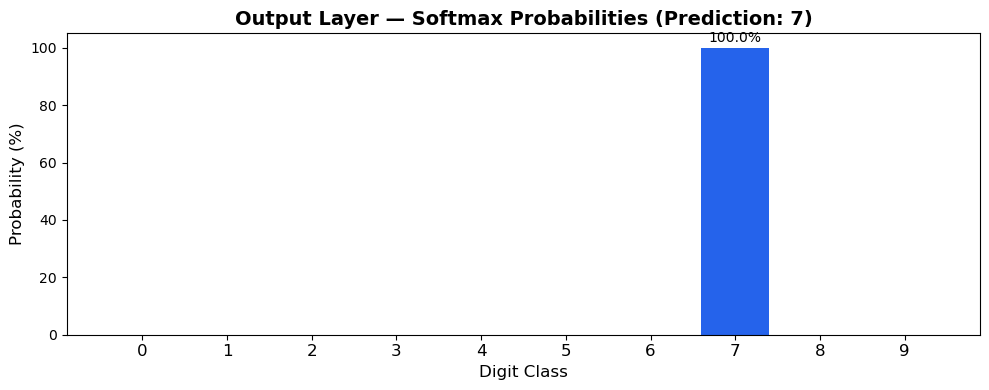

Prediction: 7 (confidence: 100.0%)
True label: 7
Probabilities sum to: 1.0000 (softmax guarantees sum = 1.0)


In [24]:
# Layer 9: Output layer — softmax probabilities for each digit
output_act = activations[9][0]  # shape: (10,)
predicted_digit = np.argmax(output_act)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2563eb' if i == predicted_digit else '#e5e7eb' for i in range(10)]
bars = ax.bar(range(10), output_act * 100, color=colors)
ax.set_xticks(range(10))
ax.set_xticklabels([str(i) for i in range(10)], fontsize=12)
ax.set_xlabel("Digit Class", fontsize=12)
ax.set_ylabel("Probability (%)", fontsize=12)
ax.set_title(f"Output Layer — Softmax Probabilities (Prediction: {predicted_digit})", fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)

# Add percentage labels on bars
for bar, prob in zip(bars, output_act):
    if prob > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{prob*100:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Prediction: {predicted_digit} (confidence: {output_act[predicted_digit]*100:.1f}%)")
print(f"True label: {sample_label}")
print(f"Probabilities sum to: {output_act.sum():.4f} (softmax guarantees sum = 1.0)")

### Comparing Activations Across Multiple Digits

To really understand what each layer learns, let's compare activations for **different digits**. This reveals how the same filters respond differently to different shapes — a "7" activates different edge detectors than a "0", for example.

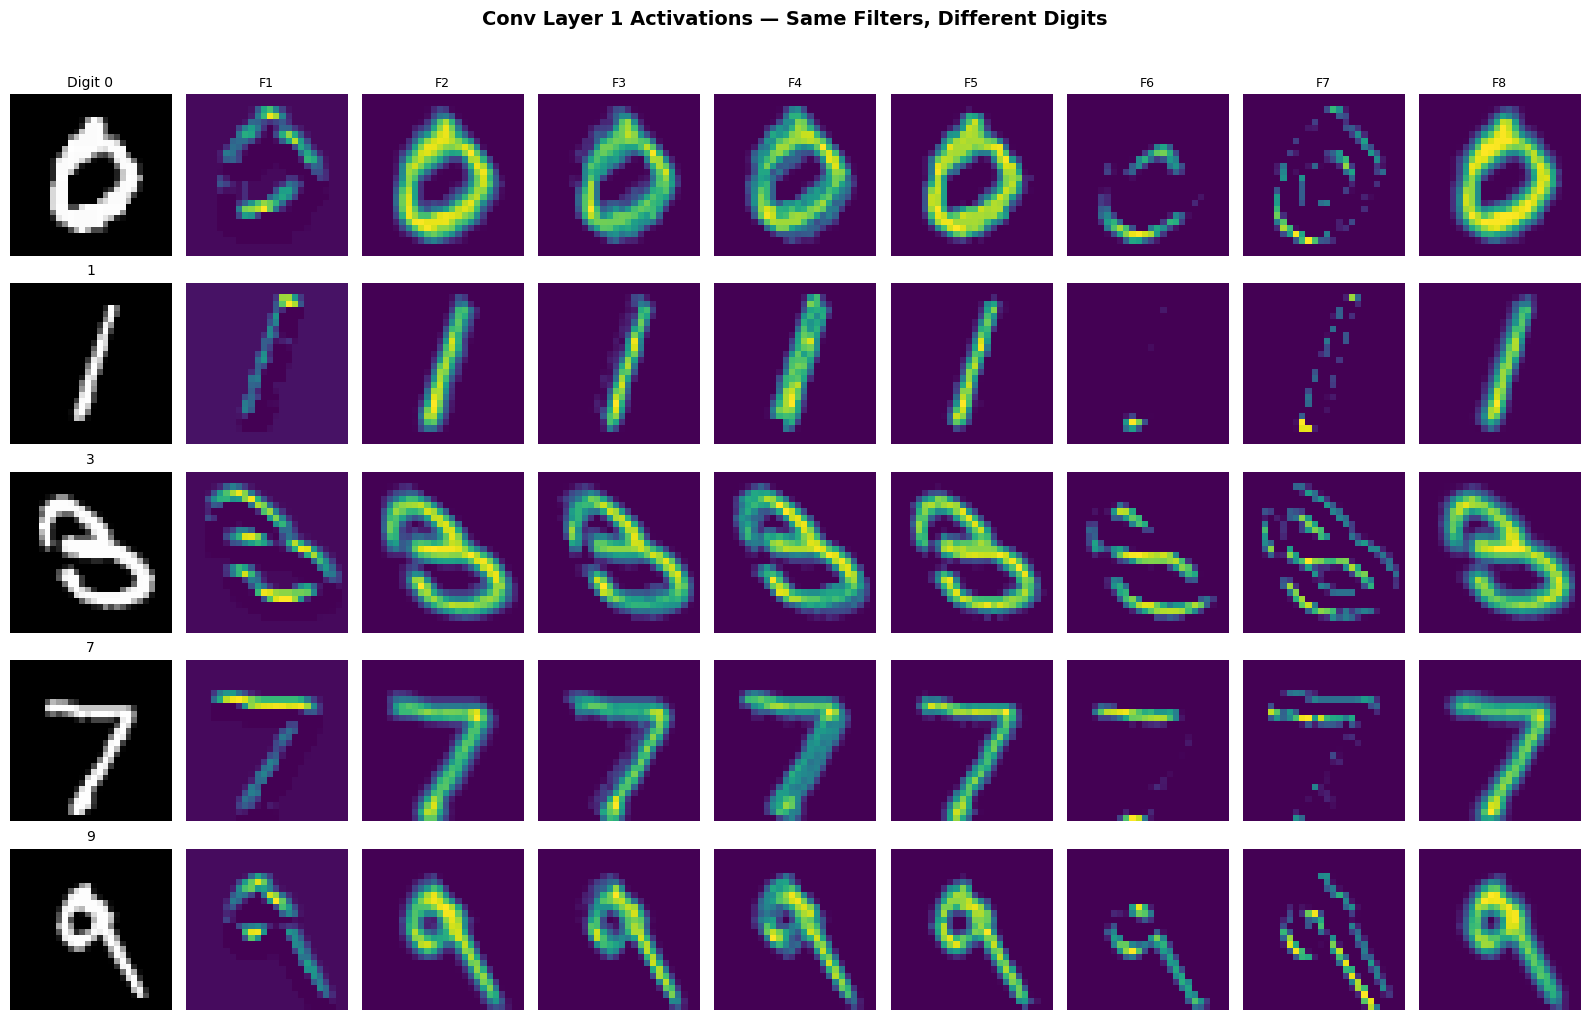

Each row shows a different digit; each column shows the same filter's response.
Notice how filters specialize: some respond to curves (strong for 0, 3, 9),
while others respond to straight lines (strong for 1, 7).


In [25]:
# Compare Conv Layer 1 activations across 5 different digits
# Find one example of each digit 0-4 in the test set
example_digits = [0, 1, 3, 7, 9]
example_indices = []
for d in example_digits:
    idx = np.where(y_test == d)[0][0]
    example_indices.append(idx)

fig, axes = plt.subplots(len(example_digits), 9, figsize=(16, len(example_digits) * 2))
fig.suptitle("Conv Layer 1 Activations — Same Filters, Different Digits", fontsize=14, fontweight='bold', y=1.02)

for row, (digit, idx) in enumerate(zip(example_digits, example_indices)):
    img = x_test[idx:idx+1]
    acts = activation_model.predict(img, verbose=0)
    conv1 = acts[0][0]  # Conv Layer 1 output

    # Show original image in first column
    axes[row, 0].imshow(img[0].squeeze(), cmap='gray')
    axes[row, 0].set_title(f"Digit {digit}" if row == 0 else f"{digit}", fontsize=10)
    axes[row, 0].axis('off')

    # Show 8 feature maps
    for f in range(8):
        axes[row, f+1].imshow(conv1[:, :, f], cmap='viridis')
        if row == 0:
            axes[row, f+1].set_title(f"F{f+1}", fontsize=9)
        axes[row, f+1].axis('off')

plt.tight_layout()
plt.show()

print("Each row shows a different digit; each column shows the same filter's response.")
print("Notice how filters specialize: some respond to curves (strong for 0, 3, 9),")
print("while others respond to straight lines (strong for 1, 7).")

## Section 9: Weight Visualization

The activations above show *what the network detects* for a specific image. Now let's look at **the weights themselves** — these are the learned parameters that define *what* each filter is looking for, regardless of the input.

### Convolutional Filter Weights

Each Conv2D filter is a small matrix of learned values. For Layer 1, each filter is 3×3×1 (one input channel). For Layer 2, each filter is 3×3×8 (eight input channels from the previous layer) — we average across input channels for visualization.

Visualizing filters reveals the **pattern templates** the CNN uses:
- Filters with alternating positive/negative values detect **edges** (transitions between light and dark)
- Filters with a central bright region detect **blobs** or **spots**
- The arrangement of positive and negative weights determines the **orientation** of the detected feature

### Dense Layer Weight Matrices

Dense layers have weight matrices connecting every input neuron to every output neuron. We visualize these as heatmaps where each row is an output neuron and each column is an input feature. Bright spots indicate strong connections.

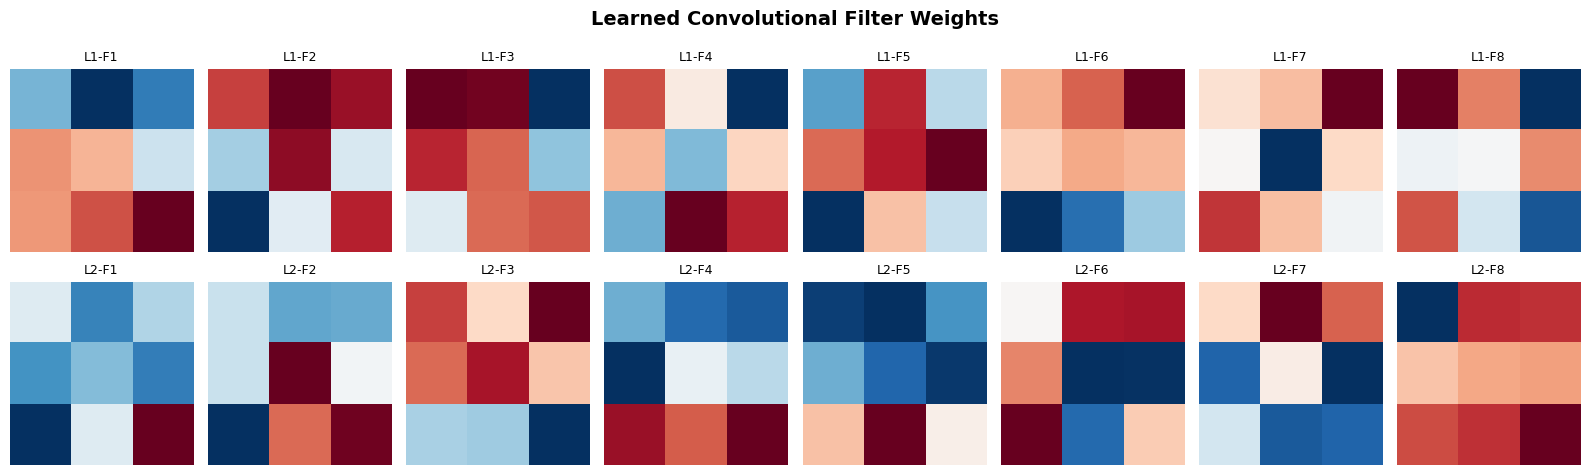

Conv Layer 1: (3, 3, 1, 8) — 8 filters of size 3×3×1 = 72 weights + 8 biases = 80 params
Conv Layer 2: (3, 3, 8, 8) — 8 filters of size 3×3×8 = 576 weights + 8 biases = 584 params
Red = positive weights (excitatory), Blue = negative weights (inhibitory)
Colormap: RdBu — centered at zero to show the sign of each weight


In [26]:
# Visualize Conv2D filter weights
conv1_weights = loaded.get_layer('conv2d_1').get_weights()[0]  # shape: (3, 3, 1, 8)
conv1_biases = loaded.get_layer('conv2d_1').get_weights()[1]   # shape: (8,)
conv2_weights = loaded.get_layer('conv2d_2').get_weights()[0]  # shape: (3, 3, 8, 8)
conv2_biases = loaded.get_layer('conv2d_2').get_weights()[1]   # shape: (8,)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Learned Convolutional Filter Weights", fontsize=14, fontweight='bold')

# Conv Layer 1 filters (3×3×1 — single input channel)
for i in range(8):
    ax = axes[0, i]
    ax.imshow(conv1_weights[:, :, 0, i], cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f"L1-F{i+1}", fontsize=9)
    ax.axis('off')
axes[0, 0].set_ylabel("Conv Layer 1", fontsize=11, rotation=0, labelpad=70, va='center')

# Conv Layer 2 filters (3×3×8 — averaged across 8 input channels)
for i in range(8):
    ax = axes[1, i]
    avg_filter = conv2_weights[:, :, :, i].mean(axis=2)  # Average across input channels
    ax.imshow(avg_filter, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f"L2-F{i+1}", fontsize=9)
    ax.axis('off')
axes[1, 0].set_ylabel("Conv Layer 2", fontsize=11, rotation=0, labelpad=70, va='center')

plt.tight_layout()
plt.show()

print(f"Conv Layer 1: {conv1_weights.shape} — 8 filters of size 3×3×1 = {8*3*3*1} weights + 8 biases = 80 params")
print(f"Conv Layer 2: {conv2_weights.shape} — 8 filters of size 3×3×8 = {8*3*3*8} weights + 8 biases = 584 params")
print(f"Red = positive weights (excitatory), Blue = negative weights (inhibitory)")
print(f"Colormap: RdBu — centered at zero to show the sign of each weight")

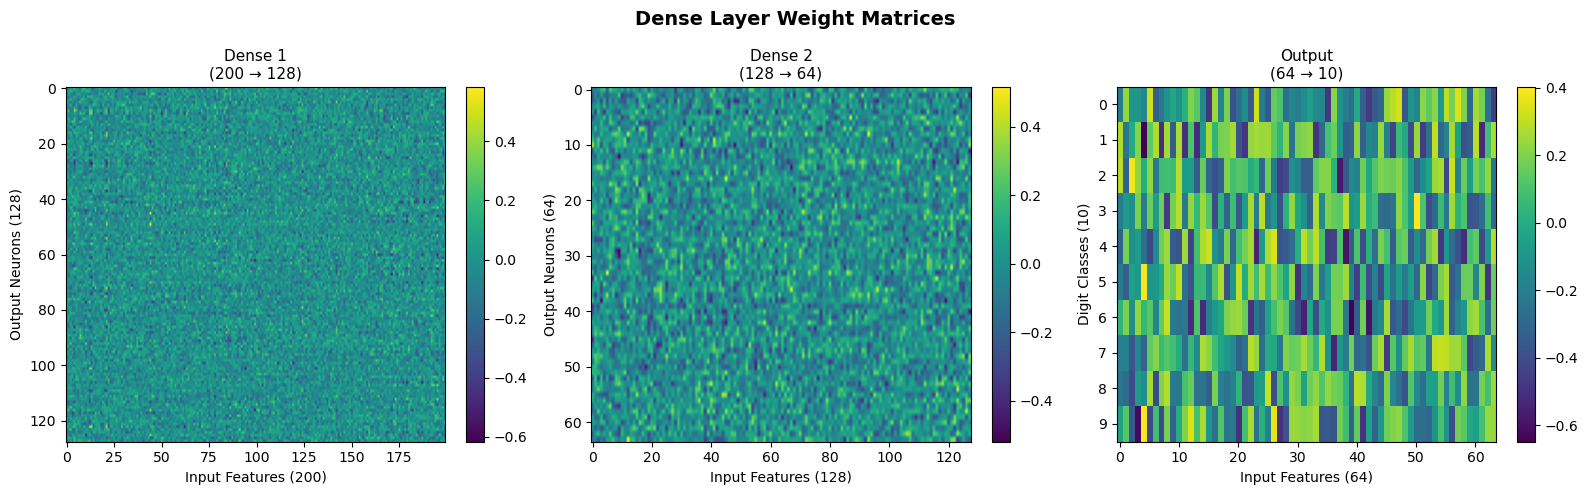

Dense Layer 1: (200, 128) = 25,600 weights
Dense Layer 2: (128, 64) = 8,192 weights
Output Layer:  (64, 10) = 640 weights
Total dense weights: 34,432

The output layer matrix is the most interpretable — each row shows which
Dense Layer 2 features contribute positively or negatively to each digit class.


In [27]:
# Visualize Dense layer weight matrices as heatmaps
dense1_w = loaded.get_layer('dense_1').get_weights()[0]  # shape: (200, 128)
dense2_w = loaded.get_layer('dense_2').get_weights()[0]  # shape: (128, 64)
output_w = loaded.get_layer('output').get_weights()[0]   # shape: (64, 10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dense Layer Weight Matrices", fontsize=14, fontweight='bold')

# Dense Layer 1: 200 → 128
im1 = axes[0].imshow(dense1_w.T, cmap='viridis', aspect='auto')
axes[0].set_title(f"Dense 1\n(200 → 128)", fontsize=11)
axes[0].set_xlabel("Input Features (200)")
axes[0].set_ylabel("Output Neurons (128)")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Dense Layer 2: 128 → 64
im2 = axes[1].imshow(dense2_w.T, cmap='viridis', aspect='auto')
axes[1].set_title(f"Dense 2\n(128 → 64)", fontsize=11)
axes[1].set_xlabel("Input Features (128)")
axes[1].set_ylabel("Output Neurons (64)")
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# Output Layer: 64 → 10
im3 = axes[2].imshow(output_w.T, cmap='viridis', aspect='auto')
axes[2].set_title(f"Output\n(64 → 10)", fontsize=11)
axes[2].set_xlabel("Input Features (64)")
axes[2].set_ylabel("Digit Classes (10)")
axes[2].set_yticks(range(10))
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Dense Layer 1: {dense1_w.shape} = {dense1_w.size:,} weights")
print(f"Dense Layer 2: {dense2_w.shape} = {dense2_w.size:,} weights")
print(f"Output Layer:  {output_w.shape} = {output_w.size:,} weights")
print(f"Total dense weights: {dense1_w.size + dense2_w.size + output_w.size:,}")
print(f"\nThe output layer matrix is the most interpretable — each row shows which")
print(f"Dense Layer 2 features contribute positively or negatively to each digit class.")

## Summary

In this notebook, we built a complete CNN pipeline for handwritten digit recognition:

1. **Data Loading** — Loaded 70,000 MNIST images from the Nielsen pickle format
2. **Preprocessing** — Reshaped flat vectors to 28×28×1 images (already normalized)
3. **Model Architecture** — Built a CNN with 2 conv blocks, 2 dense layers, dropout, and softmax output (35,298 parameters)
4. **Training** — Trained for 15 epochs with Adam optimizer, achieving ~98.7% test accuracy
5. **Evaluation** — Analyzed performance with confusion matrix and per-digit classification report
6. **Model Export** — Saved to native Keras format for the backend API to load
7. **Layer-by-Layer Activations** — Visualized what every layer "sees" when processing a digit:
   - Conv layers detect edges and patterns → pooling compresses them → dense layers classify
   - Deeper layers produce increasingly abstract representations
   - Different digits activate different filter combinations
8. **Weight Visualization** — Examined the learned filter kernels and dense weight matrices that define what the network looks for

### Key Takeaways

- **CNNs learn hierarchically:** Simple features (edges) → complex features (curves, strokes) → classification
- **Only ~200 values** (5×5×8) survive to represent the entire 784-pixel image after the conv/pool layers
- **Most dense neurons are inactive** for any given input — the network uses sparse, distributed representations
- **98.7% accuracy with only 35K parameters** shows that a well-designed small model can perform remarkably well

### Connection to the Web Application

The trained model (`model/mnist_cnn.keras`) powers the interactive frontend, where users can:
- Pick any digit and see the CNN's real-time prediction
- Explore layer-by-layer activations with viridis-colored heatmaps
- Examine trained weights and understand backpropagation
- See the full architecture with parameter counts and data flow